# Obtaining & exploring dataset

In [1]:
import numpy as np
import pandas as pd
import torch

In [2]:
import warnings
warnings.filterwarnings("ignore")


In [3]:
from gluonts.dataset.multivariate_grouper import MultivariateGrouper
from gluonts.dataset.repository.datasets import dataset_recipes, get_dataset
from pts.model.tempflow import TempFlowEstimator
from pts.model.transformer_tempflow import TransformerTempFlowEstimator
from pts import Trainer
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import MultivariateEvaluator
from gluonts.dataset.util import to_pandas
import matplotlib.pyplot as plt

In [4]:
dataset = get_dataset("solar_nips", regenerate=False)
#dataset = get_dataset("traffic_nips", regenerate=False)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
device

device(type='cuda')

In [7]:
np.random.seed(2024)
torch.manual_seed(2024)
torch.cuda.manual_seed(2024)


## Prepare dataset

In [8]:
train_grouper = MultivariateGrouper(max_target_dim=int(dataset.metadata.feat_static_cat[0].cardinality))

test_grouper = MultivariateGrouper(num_test_dates=int(len(dataset.test)/len(dataset.train)),
                                   max_target_dim=int(dataset.metadata.feat_static_cat[0].cardinality))

In [9]:
dataset_train = train_grouper(dataset.train)
dataset_test = test_grouper(dataset.test)

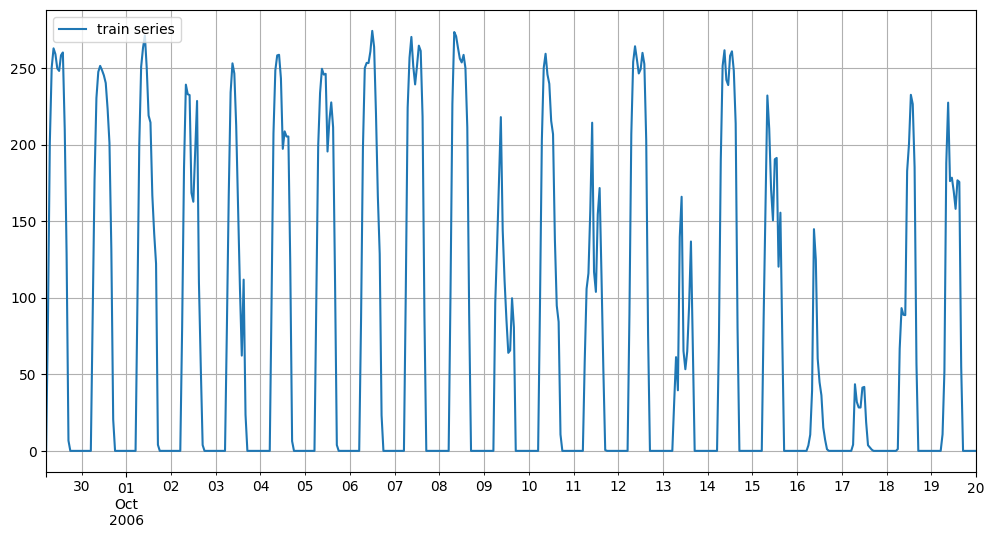

In [10]:
# Training dataset plot:

entry = next(iter(dataset.train))
train_series = to_pandas(entry)

plt.figure(figsize=(12, 6))

train_series[-500:].plot() # Plot de los 500 ultimos (es mucho toda la serie)
plt.grid(which="both")
plt.legend(["train series"], loc="upper left")
plt.show()


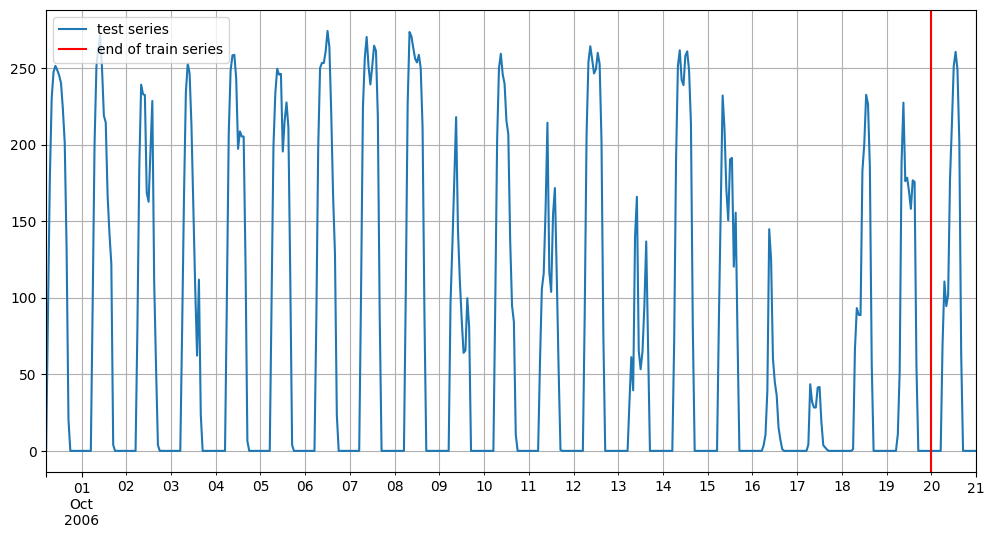

In [11]:
entry = next(iter(dataset.test))
test_series = to_pandas(entry)

plt.figure(figsize=(12, 6))

test_series[-500:].plot()
plt.axvline(train_series.index[-1], color="r")  # end of train dataset
plt.grid(which="both")
plt.legend(["test series", "end of train series"], loc="upper left")
plt.show()

In [12]:
print(
    f"Length of forecasting window in test dataset: {len(test_series) - len(train_series)}"
)
print(f"Recommended prediction horizon: {dataset.metadata.prediction_length}")
print(f"Frequency of the time series: {dataset.metadata.freq}")

Length of forecasting window in test dataset: 24
Recommended prediction horizon: 24
Frequency of the time series: H


## Evaluator

In [13]:
evaluator = MultivariateEvaluator(quantiles=(np.arange(20)/20.0)[1:],
                                  target_agg_funcs={'sum': np.sum})

## Modelo

In [14]:
#traffic
estimator = TempFlowEstimator(
    target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
    prediction_length=dataset.metadata.prediction_length,
    cell_type='GRU',
    num_cells=128,
    input_size=3856,
    freq=dataset.metadata.freq,
    scaling=True,
    flow_type='MAF',
    dropout_rate=0.3,
    trainer=Trainer(device=device,
                    epochs=25,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=32,
                    num_workers=6)
)


In [15]:
estimator = TempFlowEstimator(
    target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
    prediction_length=dataset.metadata.prediction_length,
    cell_type='GRU',
    input_size=552,
    freq=dataset.metadata.freq,
    scaling=True,
    dequantize=True,
    n_blocks=4,
    trainer=Trainer(device=device,
                    epochs=45,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=64)
)

In [16]:
#Solar nips
estimator = TempFlowEstimator(
    target_dim=int(dataset.metadata.feat_static_cat[0].cardinality),
    prediction_length=dataset.metadata.prediction_length,
    cell_type='GRU',
    input_size=552,
    freq=dataset.metadata.freq,
    scaling=True,
    dequantize=True,
    flow_type='MAF',
    trainer=Trainer(device=device,
                    epochs=25,
                    learning_rate=1e-3,
                    num_batches_per_epoch=100,
                    batch_size=64)
)

In [ ]:
predictor = estimator.train(dataset_train, prefetch_factor = None)

# Samples

In [18]:
#Aqui hare el codigo para sacar las muestras por mi cuenta. sin el uso de la función make evaluation predictions
prediction_length = predictor.prediction_length
lead_time = predictor.lead_time
freq = predictor.freq

# CODIGO PERTENECIENTE A FUNCION MAKE EVALUATION PREDICTIONS:

from typing import Dict, Iterator, NamedTuple, Optional, Tuple
from gluonts.dataset.common import DataEntry, Dataset
def add_ts_dataframe(
        data_iterator: Iterator[DataEntry],
    ) -> Iterator[DataEntry]:
        for data_entry in data_iterator:
            data = data_entry.copy()
            index = pd.date_range(
                start=data["start"],
                freq=freq,
                periods=data["target"].shape[-1],
            )
            data["ts"] = pd.DataFrame(
                index=index, data=data["target"].transpose()
            )
            yield data

def ts_iter(dataset: Dataset) -> pd.DataFrame:
        for data_entry in add_ts_dataframe(iter(dataset)):
            yield data_entry["ts"]


def truncate_target(data):
        data = data.copy()
        target = data["target"]
        assert (
            target.shape[-1] >= prediction_length
        )  # handles multivariate case (target_dim, history_length)
        data["target"] = target[..., : -prediction_length - lead_time]
        return data

from gluonts.transform import AdhocTransform
dataset_trunc = AdhocTransform(truncate_target).apply(dataset_test)

forecast_it, ts_it = predictor.predict(dataset_trunc, num_samples=100), ts_iter(dataset_test)
forecasts = list(forecast_it)
targets = list(ts_it)



TEST ----------------------------------------------
likelihoods shape: torch.Size([700, 24, 137])
log_probs:tensor([[[ 1.2472e+00, -4.1207e-01, -1.8857e+00,  ..., -2.5260e+00,
          -1.0855e+00, -2.2207e+00],
         [ 1.5966e+00,  1.2545e-01, -2.6769e+00,  ..., -4.6184e+00,
          -1.5563e+00, -2.7444e+00],
         [ 1.4622e+00, -1.2711e-01, -7.0970e-01,  ..., -3.2012e+00,
          -5.2263e-01, -1.8316e+00],
         ...,
         [ 7.8534e-01,  5.5599e-02, -1.2878e+00,  ..., -2.0251e+00,
          -6.4373e-01, -1.3323e+00],
         [ 3.9086e-02, -2.2184e-01, -6.3871e-01,  ..., -2.5398e+00,
          -1.0392e-01, -1.8319e+00],
         [ 2.1229e+00,  8.4741e-01,  9.4243e-02,  ..., -1.9886e+00,
          -8.2402e-01, -1.8101e+00]],

        [[ 1.3853e+00, -1.2389e-01, -1.5871e+00,  ..., -1.9195e+00,
          -6.5543e-01, -1.6587e+00],
         [ 1.2433e+00,  3.9158e-01, -5.6948e-01,  ..., -1.8050e+00,
          -1.7598e+00, -1.4472e+00],
         [ 1.0307e+00, -7.1491e-01, 

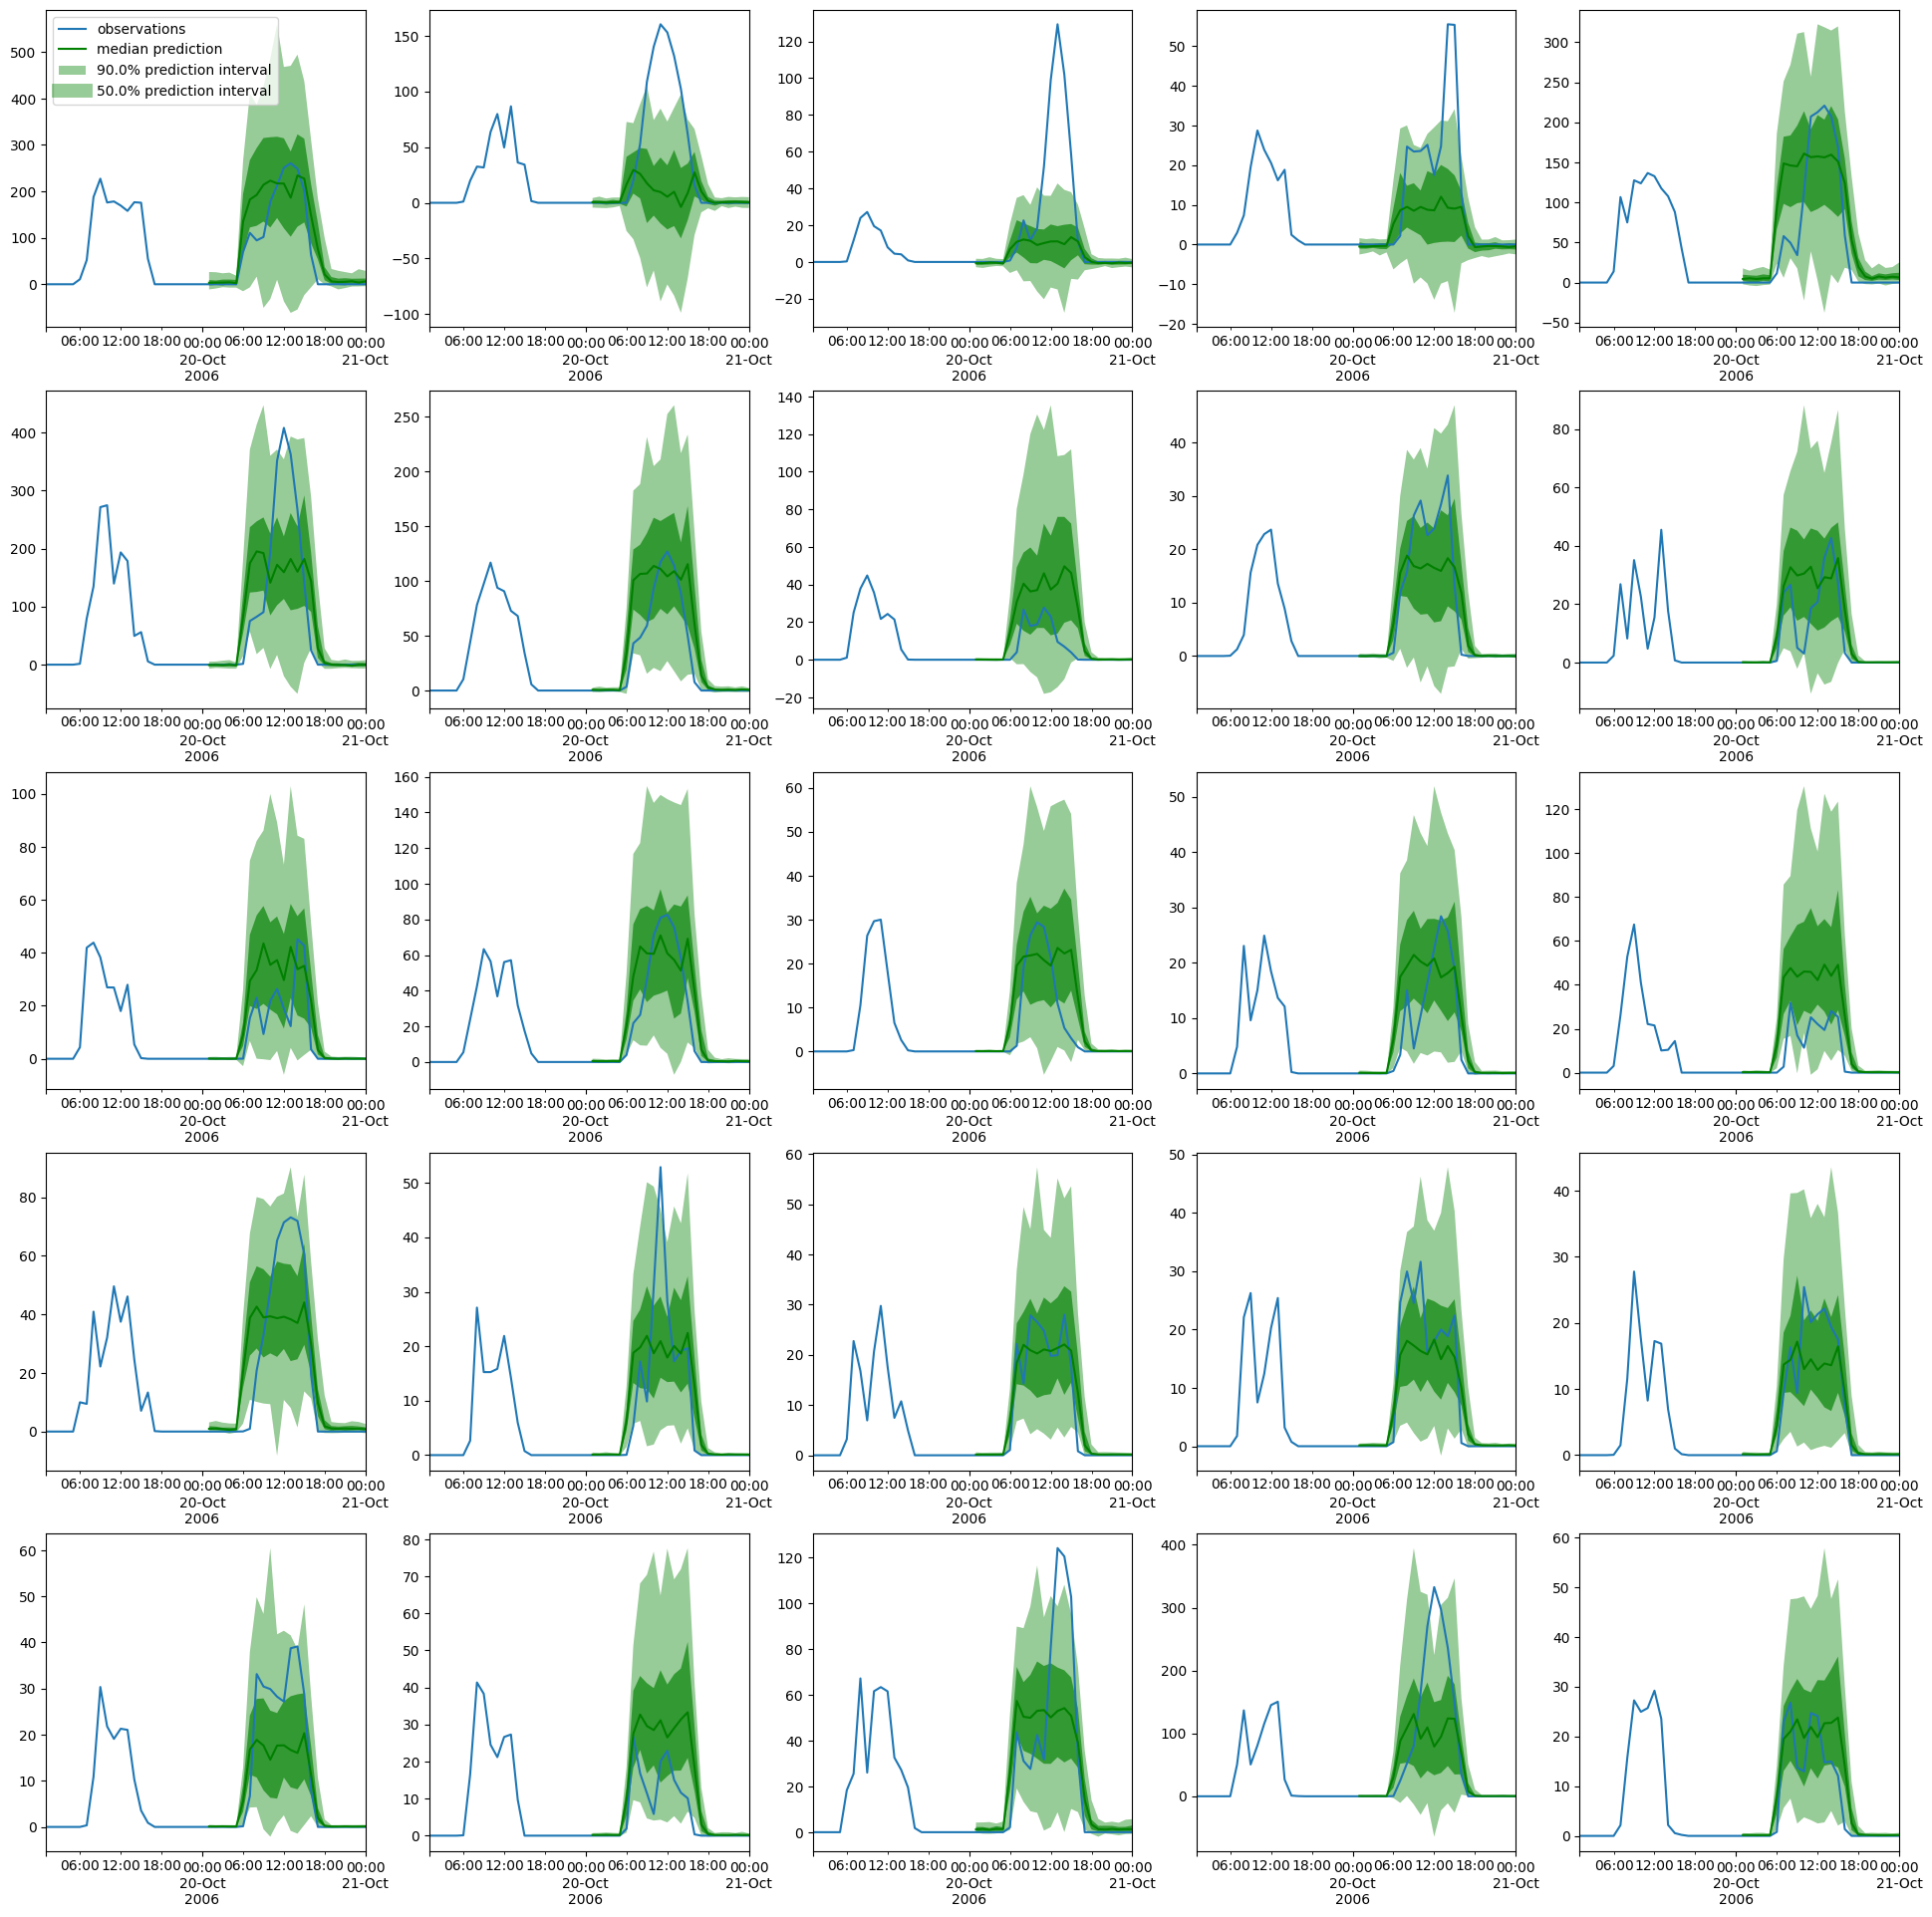

In [20]:
def plot(target, forecast, prediction_length, prediction_intervals=(50.0, 90.0), color='g', fname=None):
    label_prefix = ""
    rows = 5
    cols = 5
    fig, axs = plt.subplots(rows, cols, figsize=(24, 24))
    axx = axs.ravel()
    seq_len, target_dim = target.shape

    ps = [50.0] + [
            50.0 + f * c / 2.0 for c in prediction_intervals for f in [-1.0, +1.0]
        ]

    percentiles_sorted = sorted(set(ps))

    def alpha_for_percentile(p):
        return (p / 100.0) ** 0.3

    for dim in range(0, min(rows * cols, target_dim)):
        ax = axx[dim]

        target[-2 * prediction_length :][dim].plot(ax=ax)

        ps_data = [forecast.quantile(p / 100.0)[:,dim] for p in percentiles_sorted]
        i_p50 = len(percentiles_sorted) // 2

        p50_data = ps_data[i_p50]
        p50_series = pd.Series(data=p50_data, index=forecast.index)
        p50_series.plot(color=color, ls="-", label=f"{label_prefix}median", ax=ax)

        for i in range(len(percentiles_sorted) // 2):
            ptile = percentiles_sorted[i]
            alpha = alpha_for_percentile(ptile)
            ax.fill_between(
                forecast.index,
                ps_data[i],
                ps_data[-i - 1],
                facecolor=color,
                alpha=alpha,
                interpolate=True,
            )
            # Hack to create labels for the error intervals.
            # Doesn't actually plot anything, because we only pass a single data point
            pd.Series(data=p50_data[:1], index=forecast.index[:1]).plot(
                color=color,
                alpha=alpha,
                linewidth=10,
                label=f"{label_prefix}{100 - ptile * 2}%",
                ax=ax,
            )

    legend = ["observations", "median prediction"] + [f"{k}% prediction interval" for k in prediction_intervals][::-1]
    axx[0].legend(legend, loc="upper left")

    if fname is not None:
        plt.savefig(fname, bbox_inches='tight', pad_inches=0.05)


import matplotlib.pyplot as plt
plot(
    target=targets[0],
    forecast=forecasts[0],
    prediction_length=dataset.metadata.prediction_length,
)
plt.show()

# IMPORTANCE SAMPLING EN UNA SERIE TEMPORAL

In [20]:
#trabajando con la primera serie
muestras = forecasts[0].samples
samples = muestras[:,:,1] # prediccion ultimas 24 horas
target = targets[0][-2 * prediction_length :][1].values #48 ultimas horas
target_index = targets[0][-2 * prediction_length :][1].index


In [21]:
log_probs = forecasts[0].log_prob
#log_aprobs = forecasts[0].log_aprob

In [22]:
log_probs

array([[-362.6909 , -354.3547 , -424.23328, ..., -356.8345 , -367.0982 ,
        -322.07666],
       [-309.26755, -309.73767, -371.91068, ..., -383.79025, -372.68958,
        -326.449  ],
       [-347.8819 , -314.73248, -340.62842, ..., -332.98126, -371.92065,
        -406.66107],
       ...,
       [-394.0206 , -356.63684, -382.33685, ..., -315.21216, -310.47485,
        -339.73254],
       [-394.21375, -360.6693 , -365.72092, ..., -371.3908 , -355.21136,
        -345.16284],
       [-371.54175, -366.83844, -407.0525 , ..., -365.55084, -382.1547 ,
        -370.0346 ]], dtype=float32)

In [23]:
muestras.shape

(100, 24, 137)

In [24]:
log_probs.shape

(100, 24)

In [40]:
prueba = np.sum(log_probs, axis=-1)
prueba_prob = np.exp(prueba)

In [25]:

#log_probs = np.sum(log_probs, axis=1)
#log_aprobs = np.sum(log_aprobs, axis=1)

probs = np.exp(log_probs)
#aprobs = np.exp(log_aprobs)



In [27]:
probs[probs > 0].shape

(1096,)

In [31]:
print(probs[probs>2])

[2.0602057 3.163849  3.9160717 ... 2.0704253 2.5019095 2.45436  ]


In [31]:
probs

array([[[3.15452442e-02, 3.17945741e-02, 1.31755825e-02, ...,
         8.97153653e-03, 6.58183731e-03, 7.70590082e-03],
        [1.20910369e-02, 9.22850100e-04, 1.85453799e-02, ...,
         1.22638410e-02, 6.56790799e-03, 3.17687797e-03],
        [1.69957918e-03, 1.32468473e-02, 1.23435119e-02, ...,
         7.04125548e-03, 4.37960168e-03, 5.29338559e-03],
        ...,
        [3.14755216e-02, 3.16635296e-02, 1.94413494e-02, ...,
         4.18327749e-03, 6.12126850e-03, 7.91167282e-03],
        [1.17303059e-02, 2.64168605e-02, 6.13154843e-03, ...,
         5.80122694e-03, 1.09148864e-03, 1.02293454e-02],
        [4.01085382e-03, 3.76062058e-02, 2.43210495e-02, ...,
         1.76378805e-02, 2.38691154e-03, 1.24071250e-02]],

       [[6.14435691e-03, 3.63318883e-02, 2.08673552e-02, ...,
         2.09918451e-02, 2.69855326e-03, 1.55917296e-04],
        [2.58900668e-03, 2.57826932e-02, 2.18279101e-02, ...,
         2.12125145e-02, 1.05677666e-02, 1.91931427e-02],
        [3.02439723e-02, 

In [40]:
def rango_iqr(s, k, return_thresholds = False):
  # rango intercuantilico
  q25, q75 = np.percentile(s, 25), np.percentile(s, 75)
  iqr = q75 - q25
  # Linea de corte.
  cut_off = iqr * k
  lower, upper = q25 - cut_off, q75 + cut_off
  print(f"Lower bound: {lower}\nUpper bound: {upper}")
  if return_thresholds:
      return lower, upper
  else: # identificar valores extremos
      return [True if x < lower or x > upper else False for x in s]
  
targets_df = pd.DataFrame()
targets_df["Target"] = target
targets_df.index = target_index

def graficar_extreme_values(k):

    targets_df["Extreme value"] = targets_df[["Target"]].apply(rango_iqr, k=k)
    fig, ax = plt.subplots(figsize=(10, 6), dpi=80)

    col = np.where(targets_df['Extreme value'] == True, 'blue', 'silver')
    ax.scatter(targets_df.index, targets_df['Target'], c=col)
    ax.set_title('Extreme values para todos los años', size=18)
    ax.set_ylabel("Generacion [MW]")
    ax.set_xlabel('Fecha')

    plt.tight_layout()
    plt.show()

Lower bound: -118.72500228881836
Upper bound: 158.3000030517578


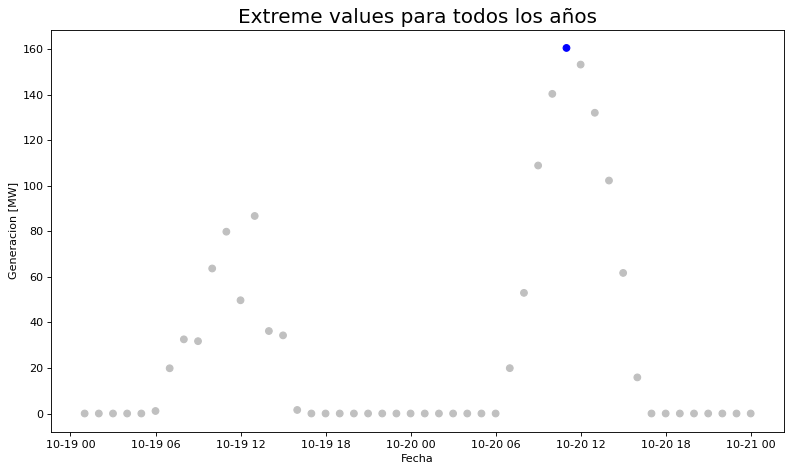

In [43]:
graficar_extreme_values(3)

In [44]:
def indicatriz(arr, alpha):
    if np.any(arr > alpha):
        return 1
    else:
        return 0
    
def MC(f, samples, alpha):
    sum = 0
    for i in range(samples.shape[0]):
        function_value = f(samples[i,:], alpha)
        sum+=function_value
    
    return (sum/samples.shape[0])


In [45]:
MC(indicatriz, samples, alpha = 158.3000030517578)

0.0

# Pruebas distribución


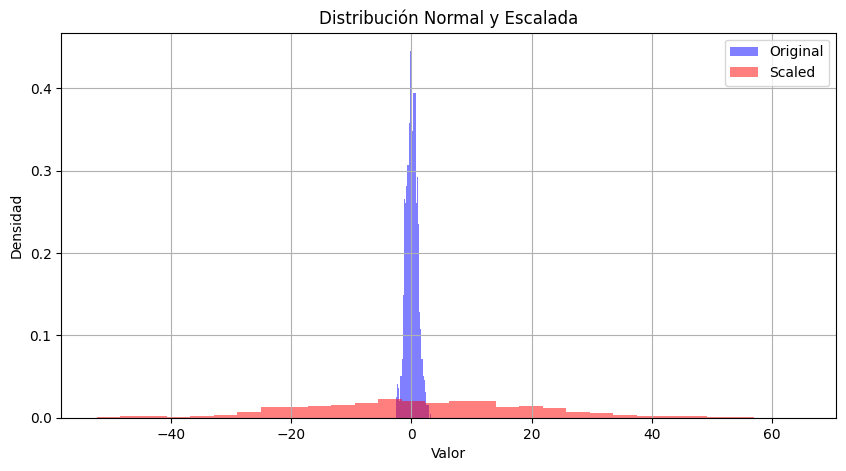

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generar muestras de una distribución normal con media 0 y desviación estándar 1
mu = 0
sigma = 1
sample_size = 1000
samples = np.random.normal(mu, sigma, sample_size)

# Graficar el histograma de las muestras originales
plt.figure(figsize=(10, 5))
plt.hist(samples, bins=30, density=True, alpha=0.5, color='b', label='Original')

# Escalar las muestras
scaled_samples = samples * 20  # Escalar por un factor de 2

# Graficar el histograma de las muestras escaladas
plt.hist(scaled_samples, bins=30, density=True, alpha=0.5, color='r', label='Scaled')

plt.title('Distribución Normal y Escalada')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.show()

# Estudio Data

In [28]:
dataset

TrainDatasets(metadata=MetaData(freq='H', target=None, feat_static_cat=[CategoricalFeatureInfo(name='feat_static_cat_0', cardinality='137')], feat_static_real=[], feat_dynamic_real=[], feat_dynamic_cat=[], prediction_length=24), train=<gluonts.dataset.common.FileDataset object at 0x0000023C886ED9A0>, test=<gluonts.dataset.common.FileDataset object at 0x0000023C886ED9D0>)

In [29]:
dataset.train

In [ ]:
predictor = estimator.train(dataset_train, prefetch_factor = None)

In [ ]:
dataset_trunc = AdhocTransform(truncate_target).apply(dataset_test)

forecast_it, ts_it = predictor.predict(dataset_trunc, num_samples=100), ts_iter(dataset_test)

In [30]:
dataset_test

In [ ]:
dataset_train = train_grouper(dataset.train)
dataset_test = test_grouper(dataset.test)

In [32]:
iter_train = next(iter(dataset_train))
iter_test = next(iter(dataset_test))

In [33]:
iter_train

{'target': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 'start': Timestamp('2006-01-01 00:00:00', freq='H'),
 'feat_static_cat': array([0]),
 'source': SourceContext(source='list_data', row=0)}

In [34]:
iter_test

{'target': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], dtype=float32),
 'start': Timestamp('2006-01-01 00:00:00', freq='H'),
 'feat_static_cat': array([0]),
 'source': SourceContext(source='list_data', row=0)}

In [38]:
iter_test["target"].shape

(137, 7033)

In [39]:
iter_train["target"].shape

(137, 7009)

In [72]:
iter_test["target"][0][7014]

69.65

In [63]:
iter_train["target"][0][7008]

0.0